# **SpaceX Falcon 9 First Stage Landing Prediction**

## EDA with Data Visualization

Estimated time needed: **70** minutes

In this lab we will perform Exploratory Data Analysis and Feature Engineering
using `Pandas`, `Matplotlib`, and `Seaborn`.

### Objectives

- Visualize relationships between features and landing outcome
- Identify success trends across flight number, payload, orbit, and year
- Prepare features via one-hot encoding for modeling

---
## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
os.makedirs('../images', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## Load the Dataset

In [2]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
print(f'Shape: {df.shape}')
df.head(5)

Shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## FlightNumber vs PayloadMass (colored by Class)

As the flight number increases, the first stage is more likely to land successfully.
Heavier payloads may reduce the likelihood of successful landing.

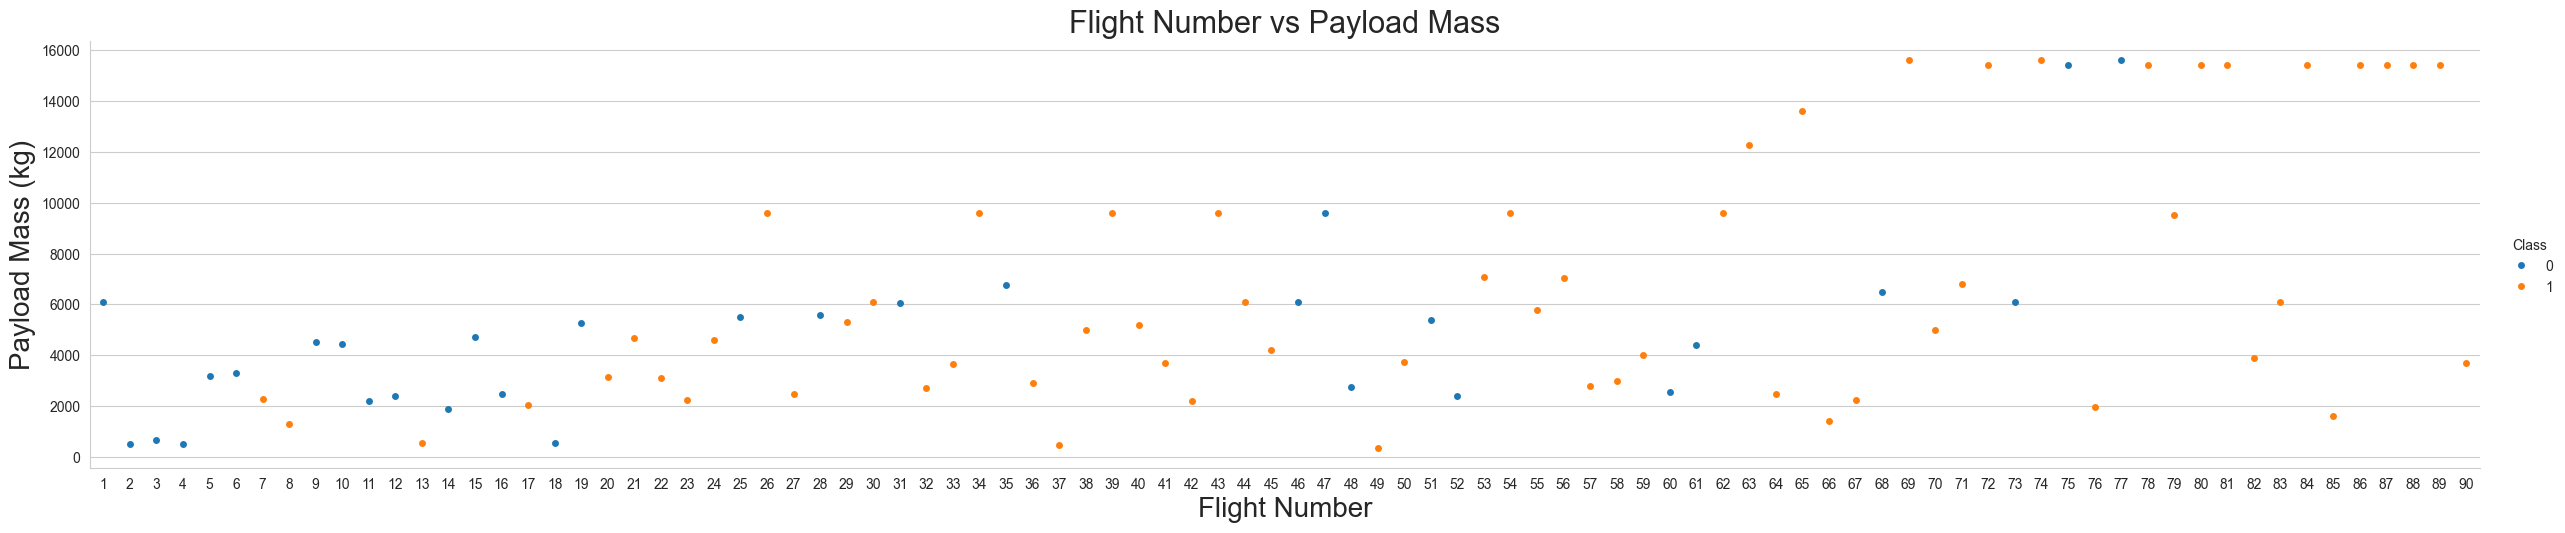

In [3]:
fig = sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.title("Flight Number vs Payload Mass", fontsize=22)
plt.savefig('../images/eda_flightnumber_vs_payloadmass.png', dpi=150, bbox_inches='tight')
plt.show()

## TASK 1: Visualize Flight Number vs Launch Site

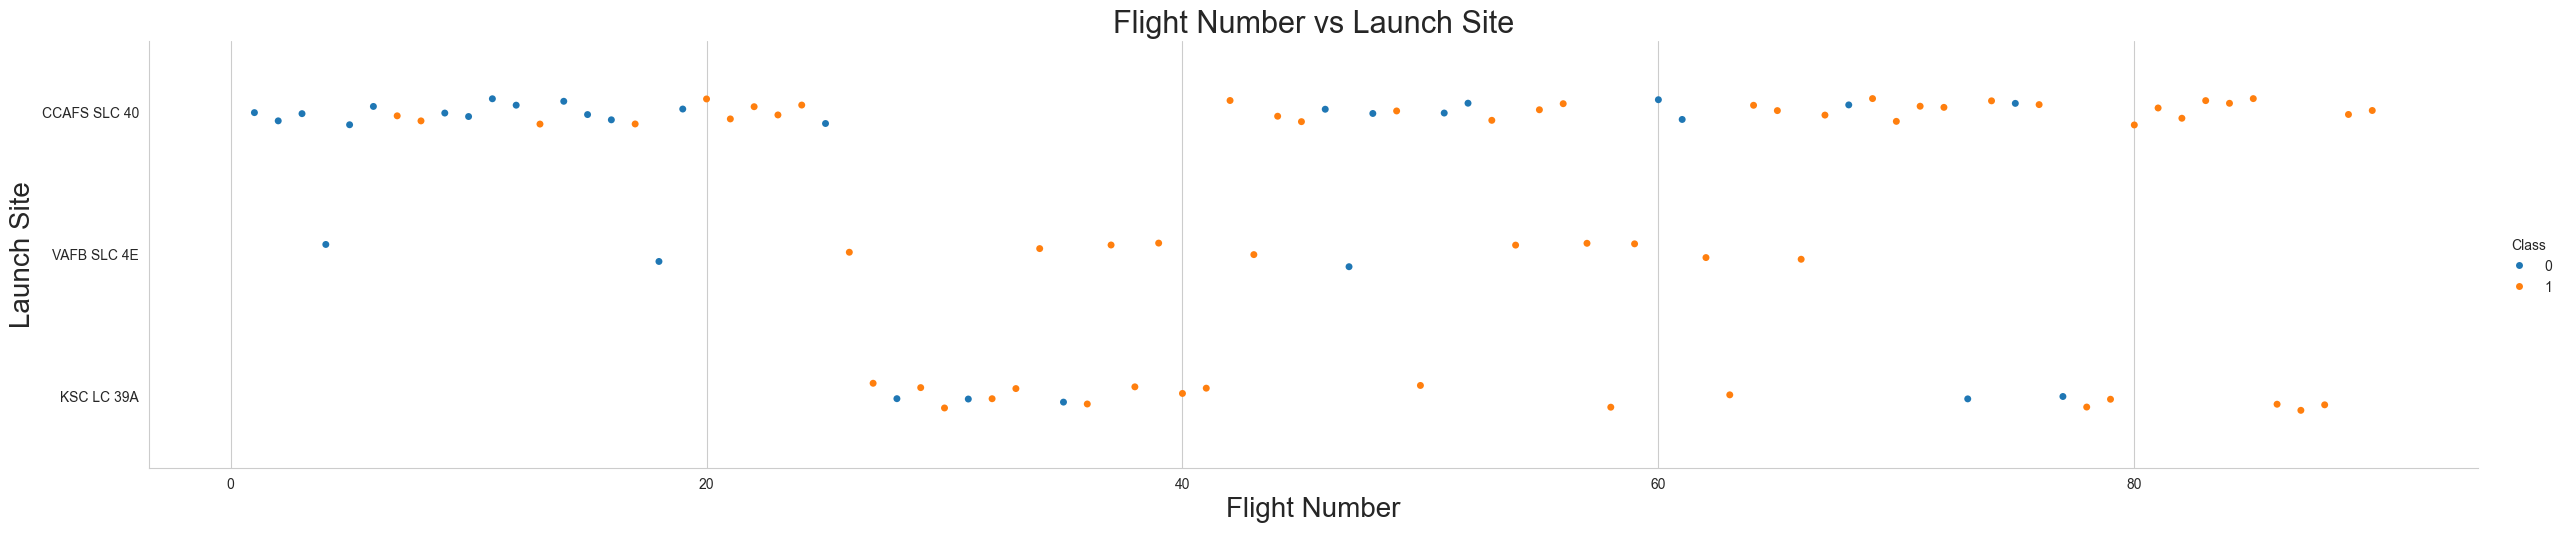

In [4]:
fig = sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Flight Number vs Launch Site", fontsize=22)
plt.savefig('../images/eda_flightnumber_vs_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** KSC LC-39A has the highest number of successful landings, especially at higher flight numbers. VAFB SLC-4E has fewer launches overall.

## TASK 2: Visualize Payload Mass vs Launch Site

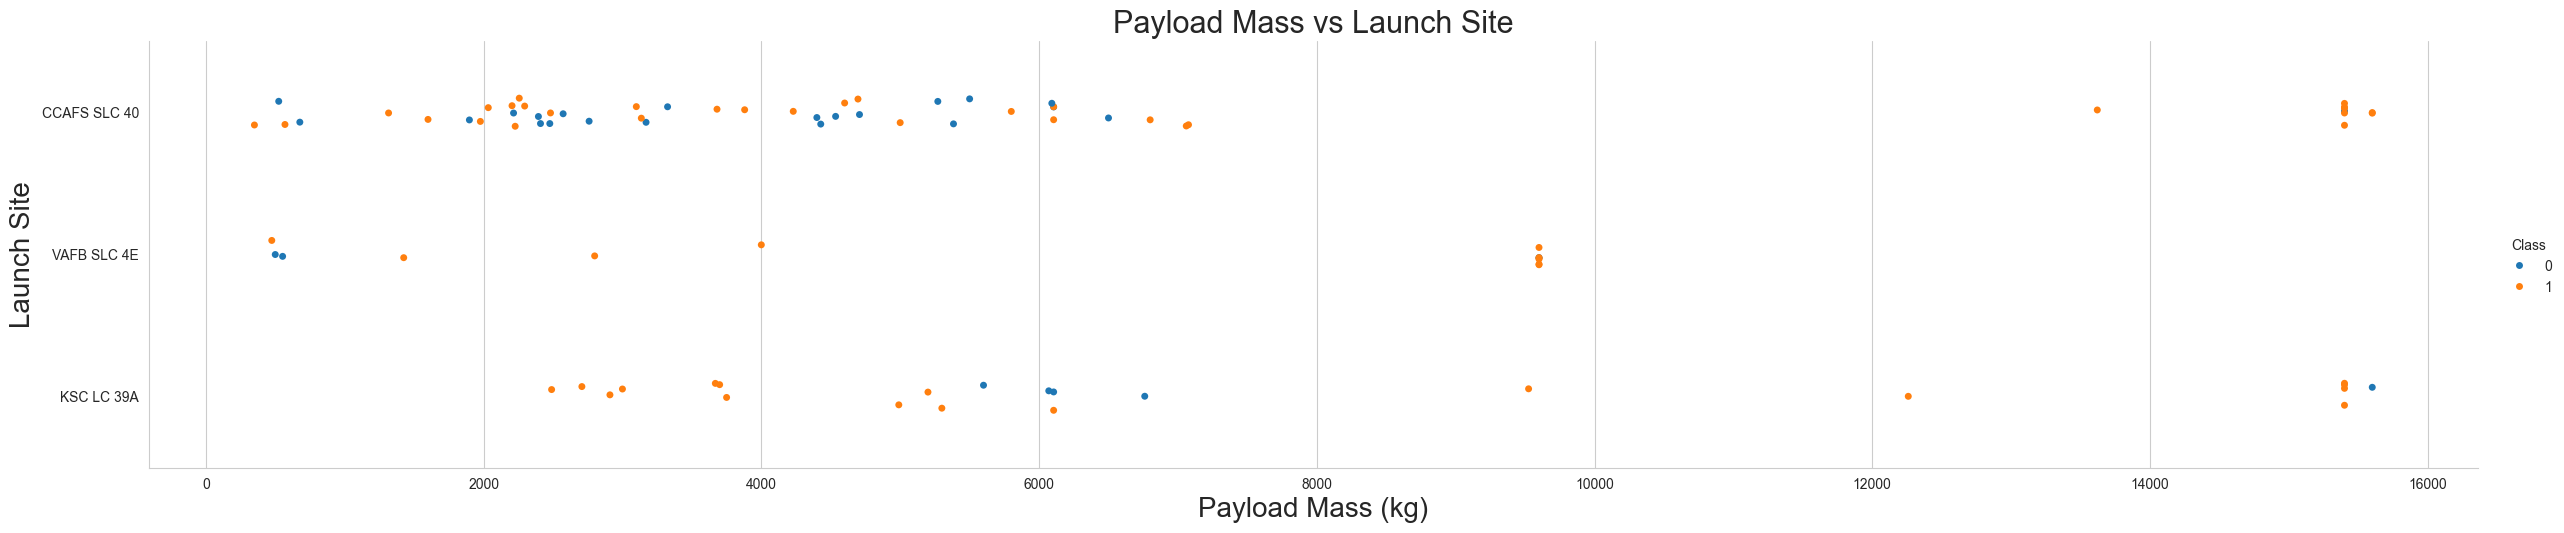

In [5]:
fig = sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Payload Mass vs Launch Site", fontsize=22)
plt.savefig('../images/eda_payloadmass_vs_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** VAFB SLC-4E has no launches with heavy payloads (> 10,000 kg). KSC LC-39A handles the heaviest payloads.

## TASK 3: Visualize Success Rate by Orbit Type

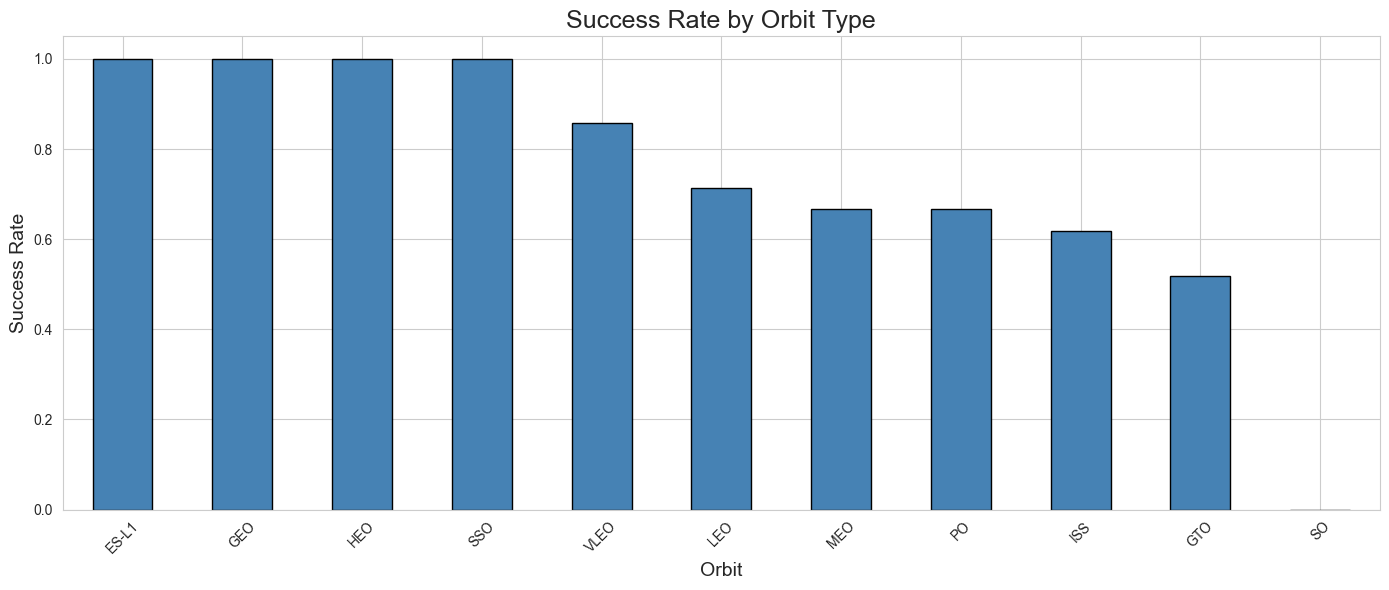

Orbit
ES-L1    1.000000
GEO      1.000000
HEO      1.000000
SSO      1.000000
VLEO     0.857143
LEO      0.714286
MEO      0.666667
PO       0.666667
ISS      0.619048
GTO      0.518519
SO       0.000000
Name: Class, dtype: float64


In [6]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
orbit_success.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Success Rate by Orbit Type', fontsize=18)
plt.xlabel('Orbit', fontsize=14)
plt.ylabel('Success Rate', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/eda_success_rate_by_orbit.png', dpi=150, bbox_inches='tight')
plt.show()

print(orbit_success)

**Observation:** ES-L1, GEO, HEO, and SSO orbits have 100% success rates. GTO has a mixed success rate.

## TASK 4: Visualize Flight Number vs Orbit Type

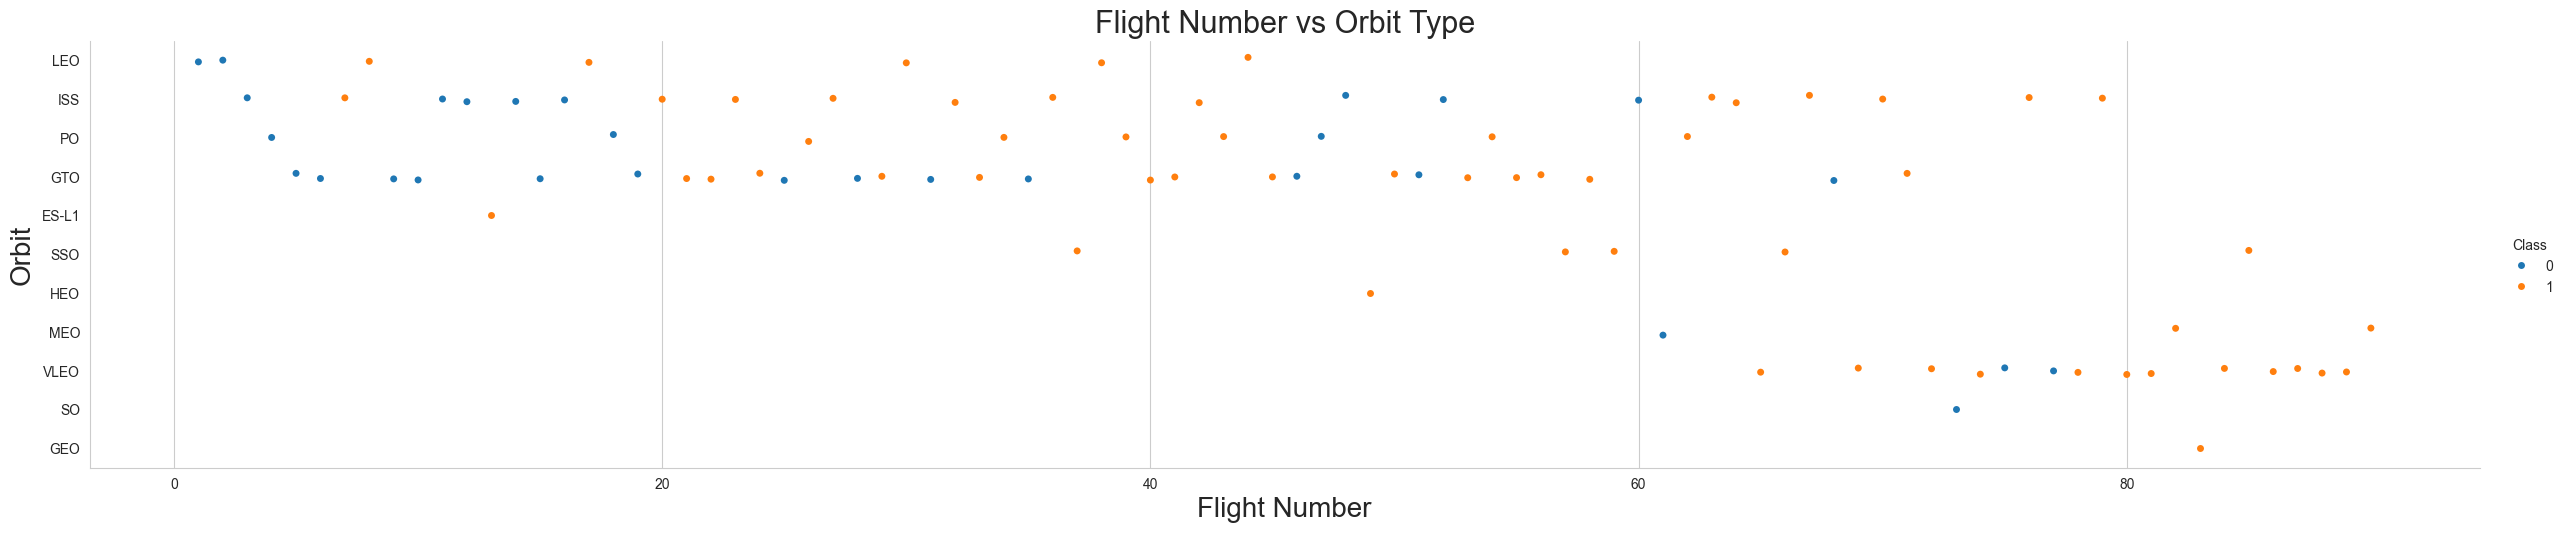

In [7]:
fig = sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.title("Flight Number vs Orbit Type", fontsize=22)
plt.savefig('../images/eda_flightnumber_vs_orbit.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** In LEO orbit, success appears related to the number of flights. In GTO orbit, there is no clear relationship.

## TASK 5: Visualize Payload Mass vs Orbit Type

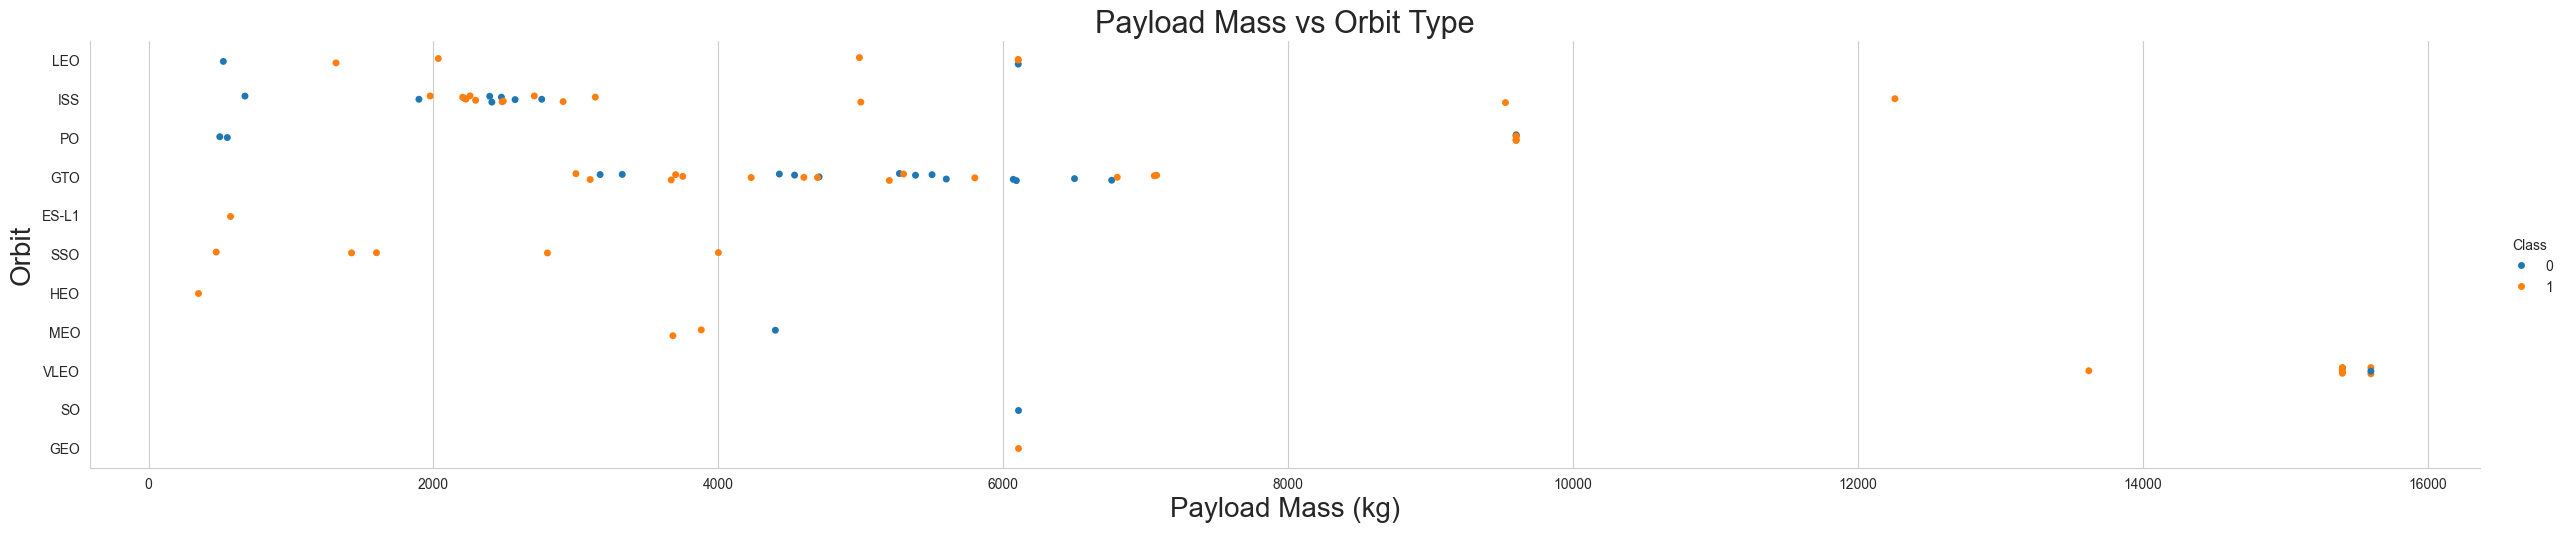

In [8]:
fig = sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.title("Payload Mass vs Orbit Type", fontsize=22)
plt.savefig('../images/eda_payloadmass_vs_orbit.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Heavy payloads have higher success rates for Polar, LEO, and ISS orbits. GTO shows mixed results for all payload ranges.

## TASK 6: Visualize Launch Success Yearly Trend

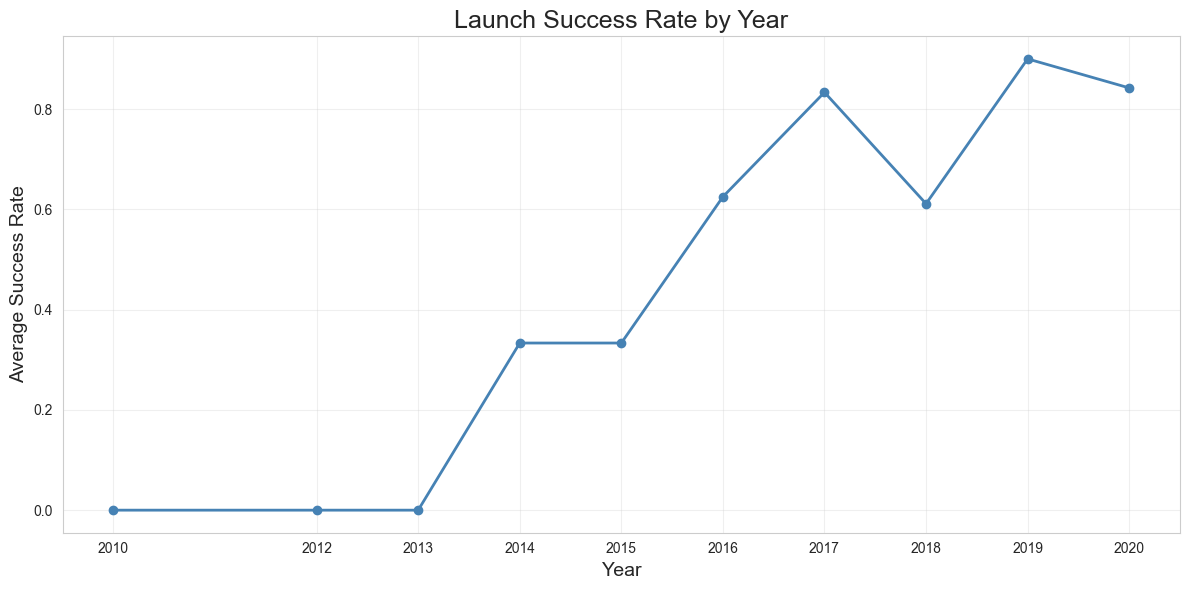

Year
2010    0.000000
2012    0.000000
2013    0.000000
2014    0.333333
2015    0.333333
2016    0.625000
2017    0.833333
2018    0.611111
2019    0.900000
2020    0.842105
Name: Class, dtype: float64


In [9]:
# Extract year from the Date column
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Calculate yearly average success rate
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_success.index, yearly_success.values, marker='o', linewidth=2, color='steelblue')
plt.title('Launch Success Rate by Year', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Success Rate', fontsize=14)
plt.xticks(yearly_success.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/eda_yearly_success_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(yearly_success)

**Observation:** The success rate has been increasing over the years, with a significant jump after 2015. By 2019-2020, the success rate is consistently above 80%.

## Launch Site Success Rate (Bar Chart)

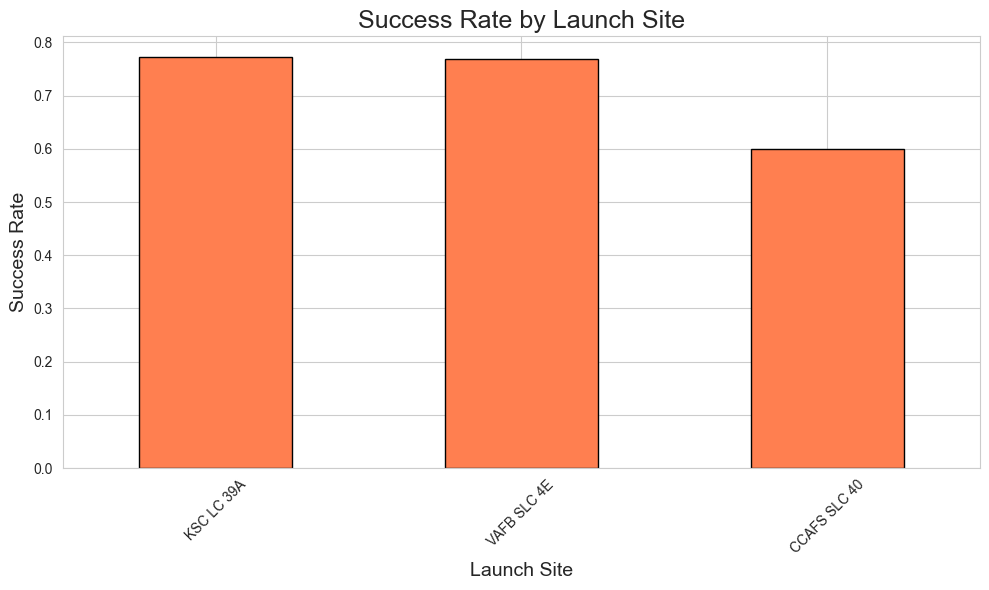

LaunchSite
KSC LC 39A      0.772727
VAFB SLC 4E     0.769231
CCAFS SLC 40    0.600000
Name: Class, dtype: float64


In [10]:
site_success = df.groupby('LaunchSite')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
site_success.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Success Rate by Launch Site', fontsize=18)
plt.xlabel('Launch Site', fontsize=14)
plt.ylabel('Success Rate', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/eda_success_rate_by_site.png', dpi=150, bbox_inches='tight')
plt.show()

print(site_success)

## Feature Engineering

Select features for modeling and apply one-hot encoding to categorical columns.

### TASK 7: Create Dummy Variables for Categorical Columns

In [11]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite',
               'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad',
               'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [12]:
# Apply OneHotEncoder using get_dummies on categorical columns
features_one_hot = pd.get_dummies(features,
                                   columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
print(f'Shape after one-hot encoding: {features_one_hot.shape}')
features_one_hot.head()

Shape after one-hot encoding: (90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK 8: Cast All Numeric Columns to float64

In [13]:
features_one_hot = features_one_hot.astype('float64')
print(features_one_hot.dtypes)

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object


## Save Engineered Features to CSV

In [14]:
output_path = '../data/dataset_part_3.csv'
features_one_hot.to_csv(output_path, index=False)
print(f'Saved {features_one_hot.shape[0]} rows × {features_one_hot.shape[1]} columns to {output_path}')

Saved 90 rows × 80 columns to ../data/dataset_part_3.csv


## Summary

In this notebook we:

1. **Visualized** FlightNumber vs PayloadMass, Launch Site, and Orbit relationships
2. **Created** bar charts for success rates by orbit and launch site
3. **Plotted** the yearly success rate trend showing improvement over time
4. **Performed** feature engineering with one-hot encoding
5. **Saved** all charts to `images/` and engineered features to `data/dataset_part_3.csv`

### Key Findings

- KSC LC-39A has the highest success rate among launch sites
- ES-L1, GEO, HEO, SSO orbits have 100% success rates
- Success rate has consistently improved over the years
- Higher flight numbers correlate with more successful landings